<a href="https://colab.research.google.com/github/yosungcho/yosungcho.github.io/blob/main/12132025GlaucomaResnet18Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using device: cpu
Checking data folder: /content/drive/MyDrive/Jojo CNN/Glaucoma/Images
SUCCESS: Image folder found at '/content/drive/MyDrive/Jojo CNN/Glaucoma/Images'
Loaded 1879 images
Normal cases: 973, Glaucoma cases: 906

Training set: 1202 images
Validation set: 301 images
Test set: 376 images

BUILDING RESNET18 MODEL WITH TRANSFER LEARNING

Model architecture:
  Base: ResNet18 (pretrained on ImageNet)
  Frozen layers: conv1 through layer3
  Trainable: layer4 + custom classifier
  Total parameters: 11,308,097
  Trainable parameters: 8,525,313

TRAINING RESNET18 MODEL
Epoch   1/20 | Train Loss: 0.4988 | Train Acc: 0.7646 | Val Loss: 0.2534 | Val Acc: 0.8837
  ✓ New best model saved!
Epoch   2/20 | Train Loss: 0.3338 | Train Acc: 0.8527 | Val Loss: 0.1987 | Val Acc: 0.9169
  ✓ New best model saved!
Epoch   3/20 | Train Loss: 0.2854 | Train Acc: 0.8819 | Val Loss: 0.2099 | Val Acc: 0.9070
Epoch   4/20 | Train Loss: 0.2577 | Train Acc: 0.8902 | Val Loss: 0.1976 | Val Acc: 0.9169
  ✓

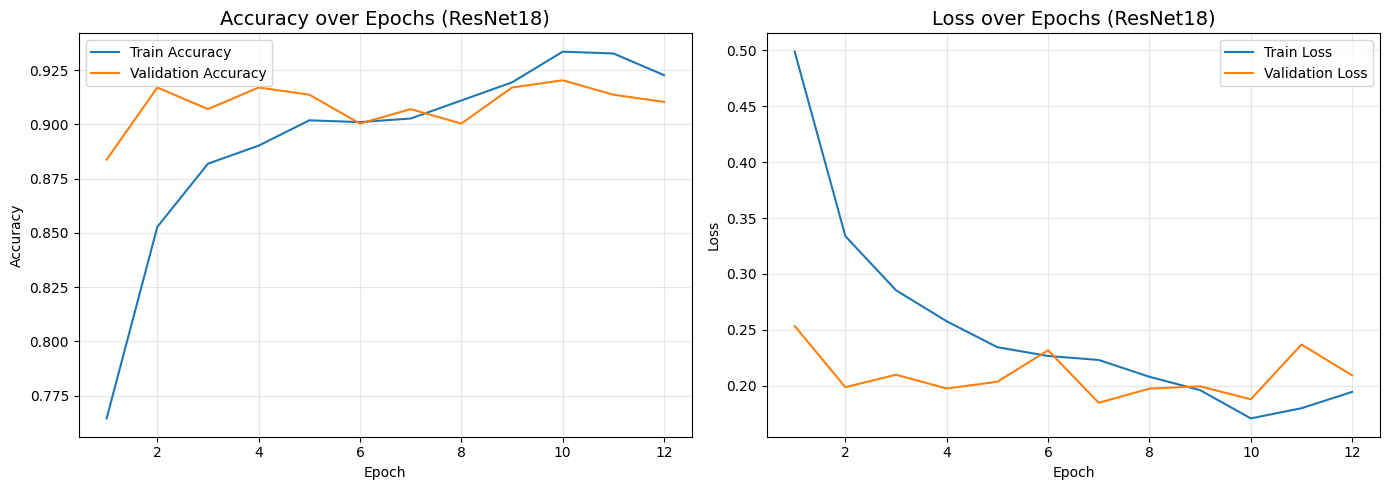


STANDARD BINARY METRICS (Threshold = 0.5)
Test F1 Score: 0.9000


<Figure size 600x600 with 0 Axes>

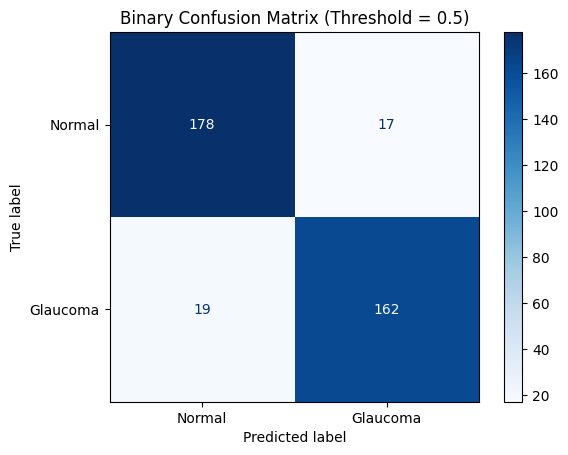

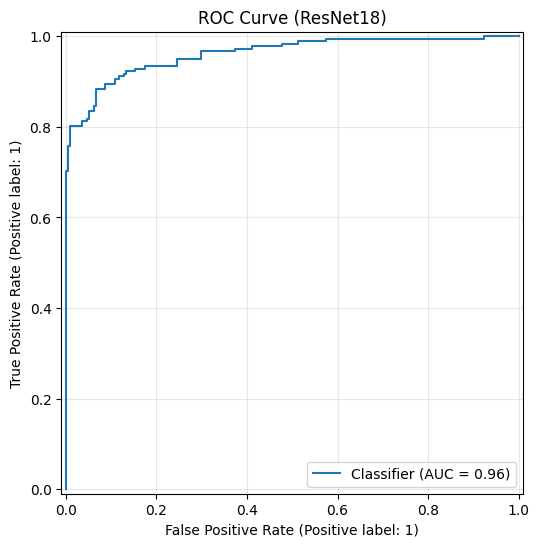

ROC AUC: 0.9614


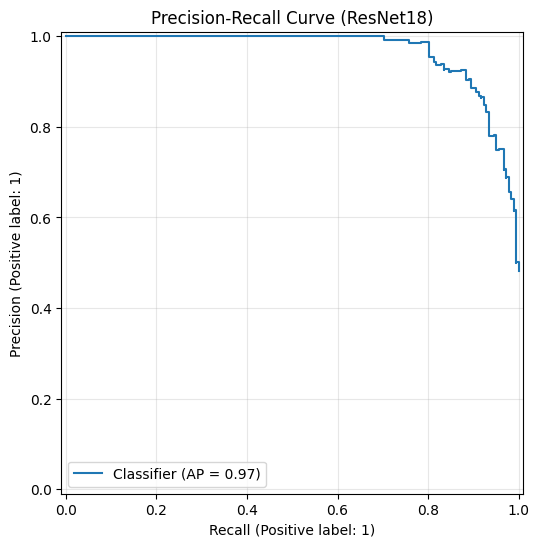


THREE-CATEGORY CLASSIFICATION WITH UNCERTAINTY ZONE

Classification Rules:
  • Prediction ≤ 0.2  → NORMAL (High Confidence)
  • Prediction 0.2-0.8 → UNCERTAIN (Needs Review)
  • Prediction ≥ 0.8  → GLAUCOMA (High Confidence)

THREE-CATEGORY CONFUSION MATRIX

                        PREDICTED
              Normal    Uncertain   Glaucoma
              (≤0.2)    (0.2-0.8)    (≥0.8)
          ┌──────────┬───────────┬──────────┐
   Normal │   155    │     34    │     6    │
  ACTUAL  ├──────────┼───────────┼──────────┤
 Glaucoma │    12    │     24    │   145    │
          └──────────┴───────────┴──────────┘

DETAILED THREE-CATEGORY METRICS

1. HIGH-CONFIDENCE ACCURACY:
   When AI is confident (≤0.2 or ≥0.8):
   Correct: 300/318 = 94.34%

2. UNCERTAINTY RATE:
   Cases flagged for review: 58/376 = 15.43%

3. ERROR RATES:
   False Positives (Normal → Glaucoma): 6/195 = 3.08%
   False Negatives (Glaucoma → Normal): 12/181 = 6.63%

4. DETECTION RATES:
   High-Confidence Detection: 145/181 = 8

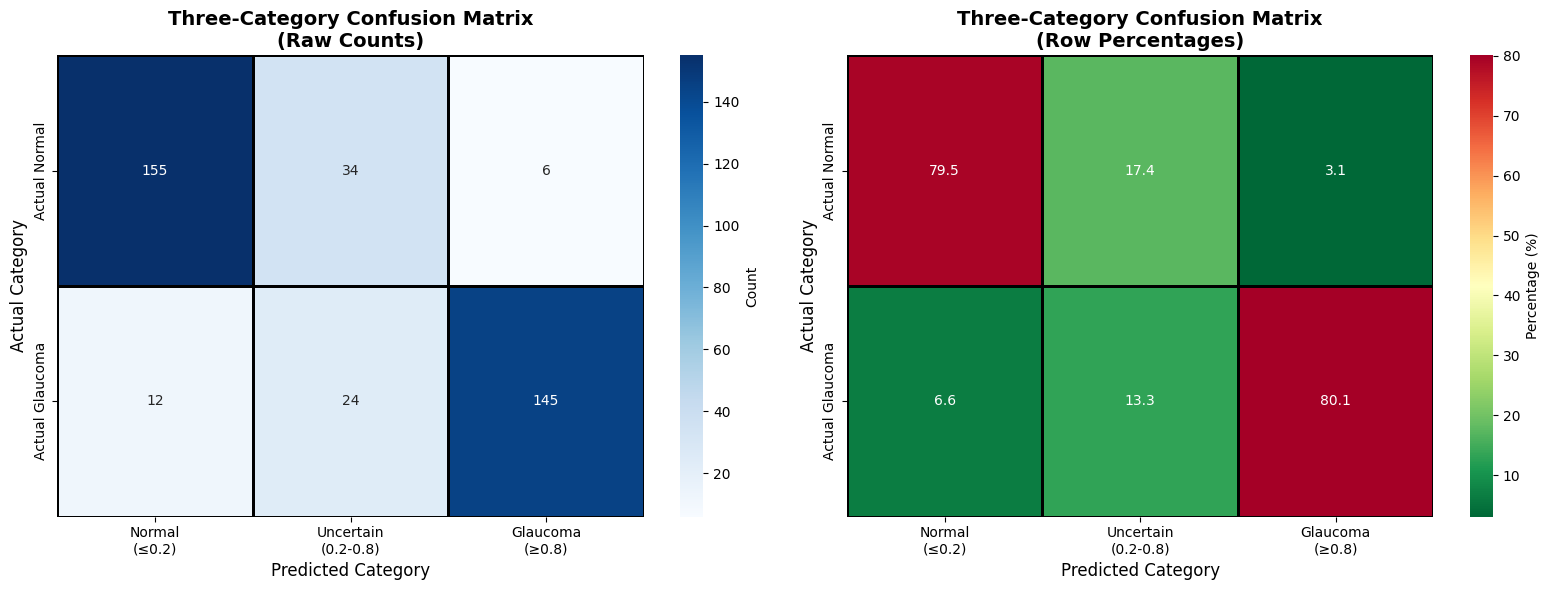


PREDICTION SCORE DISTRIBUTION


/tmp/ipython-input-4000659150.py:530: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1, 0].boxplot(data_for_box, labels=['Actual Normal', 'Actual Glaucoma'],


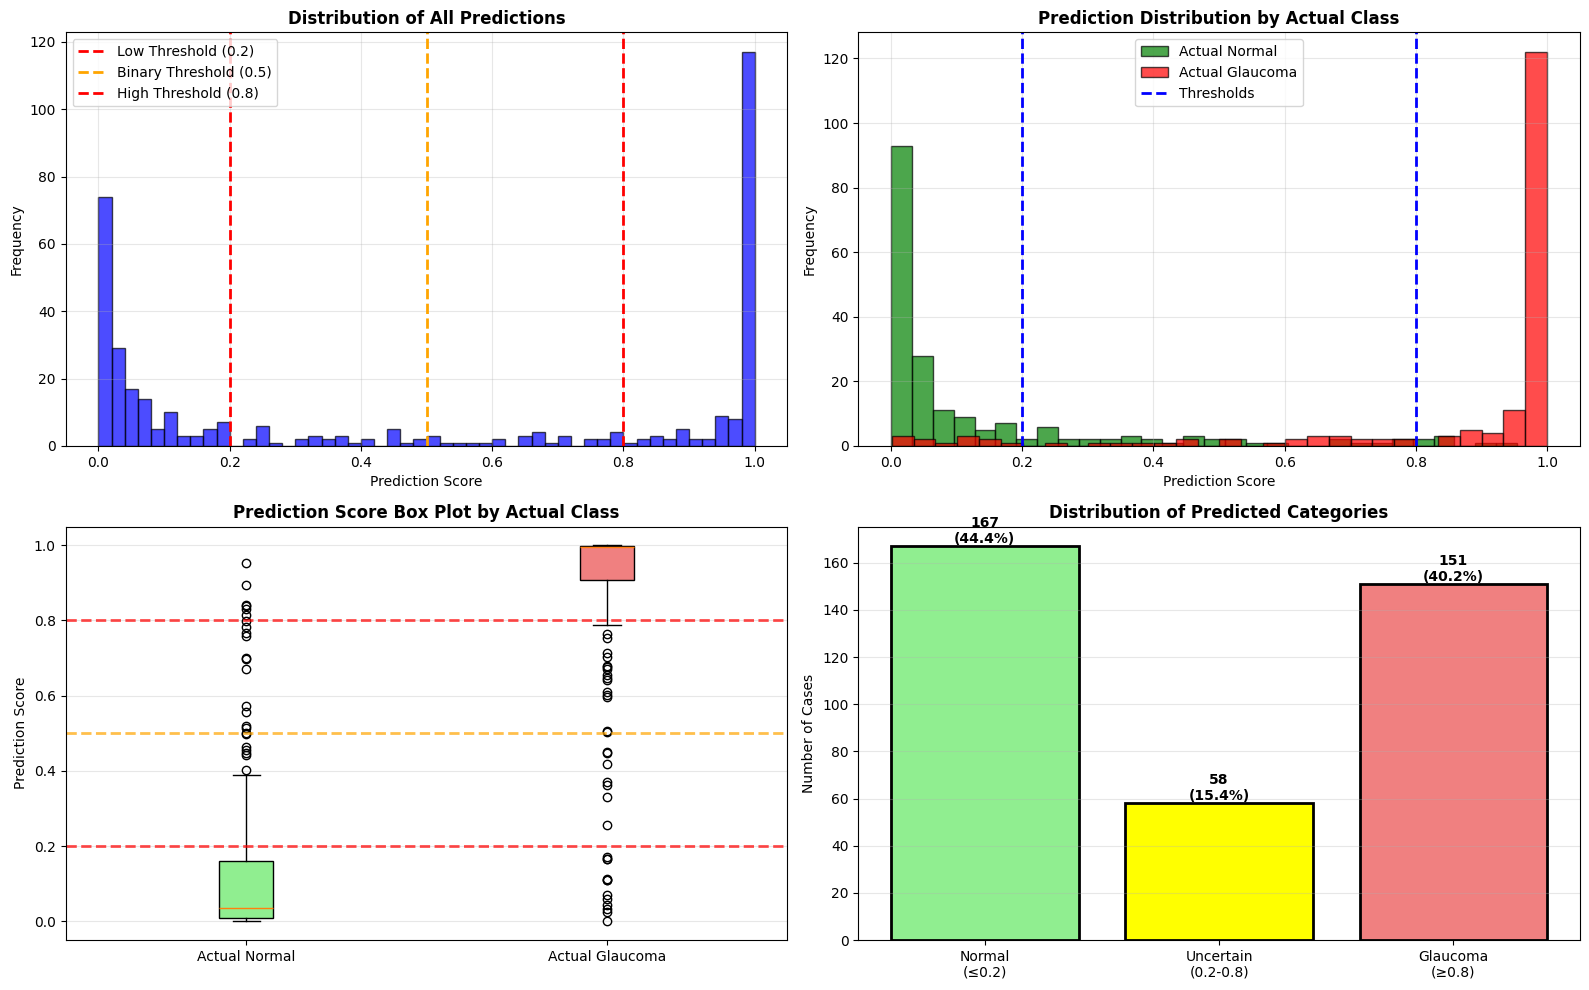


COMPARISON: BINARY vs THREE-CATEGORY SYSTEMS

                   Metric Binary System (0.5 threshold) Three-Category System (0.2/0.8)
      Accuracy (Overall)                        90.43%                          79.79%
High-Confidence Accuracy                           N/A                          94.34%
     False Positive Rate                         8.72%                           3.08%
     False Negative Rate                        10.50%                           6.63%
    Cases Needing Review                            0%                          15.43%
 Glaucoma Detection Rate                        89.50%                          93.37%

LED COMMAND EXAMPLES FOR THREE-CATEGORY SYSTEM

Example Prediction Scores → LED Commands:
--------------------------------------------------
Score: 0.05 → LED: '0' (OFF) → Normal (High Confidence)
Score: 0.15 → LED: '0' (OFF) → Normal (High Confidence)
Score: 0.35 → LED: 'A' (BLINK) → Uncertain (Needs Review)
Score: 0.50 → LED: 'A' (BLINK) 

ModuleNotFoundError: No module named 'onnxscript'

In [ ]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import copy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torch.optim.lr_scheduler import ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay,
    PrecisionRecallDisplay
)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# === 2. LOAD LABELS ===
label_file = '/content/drive/MyDrive/Jojo CNN/Glaucoma/Excel/Labels.csv'
df = pd.read_csv(label_file)
label_map = {
    str(r['imageID']).strip().lower(): int(r['binaryLabels'])
    for _, r in df.iterrows()
}

# === 3. CUSTOM DATASET CLASS ===
class GlaucomaDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]

        # Convert numpy array to PIL Image for transforms
        if isinstance(image, np.ndarray):
            image = Image.fromarray((image * 255).astype(np.uint8))

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.float32)

# === 4. DATA TRANSFORMS ===
# ResNet expects 224x224 images with ImageNet normalization
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# === 5. IMAGE LOADING FUNCTION ===
def load_images(folder_path):
    """Load images as PIL-ready numpy arrays (0-1 range)"""
    images, labels = [], []
    if not os.path.exists(folder_path):
        raise FileNotFoundError(f"Image folder not found: {folder_path}")

    for fname in os.listdir(folder_path):
        if not fname.lower().endswith('.jpg'):
            continue
        img_id = fname.strip().lower()
        if img_id not in label_map:
            print(f"Missing label for {fname}")
            continue
        try:
            img = Image.open(Path(folder_path)/fname).convert('RGB')
            img = img.resize((IMG_SIZE, IMG_SIZE))
            images.append(np.array(img)/255.0)
            labels.append(label_map[img_id])
        except Exception as e:
            print(f"Error processing {fname}: {e}")

    return np.array(images, dtype=np.float32), np.array(labels, dtype=np.int32)

# === 6. LOAD DATA ===
data_folder = '/content/drive/MyDrive/Jojo CNN/Glaucoma/Images'

print(f"Checking data folder: {data_folder}")
if not os.path.exists(data_folder):
    print(f"ERROR: Image folder not found at '{data_folder}'")
    print("Please verify the path to your image folder in Google Drive.")
    print("\nContents of /content/drive/MyDrive/ (top level):")
    for item in os.listdir('/content/drive/MyDrive/'):
        print(f"- {item}")
    raise FileNotFoundError(f"Image folder not found: {data_folder}")
else:
    print(f"SUCCESS: Image folder found at '{data_folder}'")

X, y = load_images(data_folder)
if X.size == 0:
    raise RuntimeError("No images loaded—please check your path.")

print(f"Loaded {len(X)} images")
print(f"Normal cases: {np.sum(y == 0)}, Glaucoma cases: {np.sum(y == 1)}")

# === 7. TRAIN/VAL/TEST SPLIT ===
# First split: 80% train+val, 20% test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Second split: 80% train, 20% val (from trainval)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=42, stratify=y_trainval
)

print(f"\nTraining set: {len(X_train)} images")
print(f"Validation set: {len(X_val)} images")
print(f"Test set: {len(X_test)} images")

# === 8. CREATE DATA LOADERS ===
BATCH_SIZE = 32

train_dataset = GlaucomaDataset(X_train, y_train, transform=train_transform)
val_dataset = GlaucomaDataset(X_val, y_val, transform=val_transform)
test_dataset = GlaucomaDataset(X_test, y_test, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# === 9. BUILD RESNET18 MODEL ===
print("\n" + "="*60)
print("BUILDING RESNET18 MODEL WITH TRANSFER LEARNING")
print("="*60)

def build_resnet18_model(num_classes=1, freeze_layers=True):
    """
    Build ResNet18 with pretrained ImageNet weights
    Modified for binary classification
    """
    # Load pretrained ResNet18
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    # Optionally freeze early layers
    if freeze_layers:
        # Freeze all layers except layer4 and fc
        for name, param in model.named_parameters():
            if 'layer4' not in name and 'fc' not in name:
                param.requires_grad = False

    # Replace final fully connected layer
    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(num_features, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, num_classes),
        nn.Sigmoid()
    )

    return model

model = build_resnet18_model(freeze_layers=True)
model = model.to(device)

# Print model summary
print(f"\nModel architecture:")
print(f"  Base: ResNet18 (pretrained on ImageNet)")
print(f"  Frozen layers: conv1 through layer3")
print(f"  Trainable: layer4 + custom classifier")
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")

# === 10. TRAINING SETUP ===
criterion = nn.BCELoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# === 11. TRAINING FUNCTION ===
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler,
                num_epochs=20, patience=5):
    """
    Train model with early stopping
    """
    best_val_loss = float('inf')
    best_model_wts = copy.deepcopy(model.state_dict())
    epochs_no_improve = 0

    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': []
    }

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device).unsqueeze(1)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            predicted = (outputs > 0.5).float()
            train_correct += (predicted == labels).sum().item()
            train_total += labels.size(0)

        train_loss = train_loss / train_total
        train_acc = train_correct / train_total

        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device).unsqueeze(1)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                predicted = (outputs > 0.5).float()
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

        val_loss = val_loss / val_total
        val_acc = val_correct / val_total

        # Update scheduler
        scheduler.step(val_loss)

        # Save history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1:3d}/{num_epochs} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

        # Early stopping check
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
            print(f"  ✓ New best model saved!")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"\nEarly stopping triggered after {epoch+1} epochs")
                break

    # Load best model weights
    model.load_state_dict(best_model_wts)
    return model, history

# === 12. TRAIN MODEL ===
print("\n" + "="*60)
print("TRAINING RESNET18 MODEL")
print("="*60)

model, history = train_model(
    model, train_loader, val_loader,
    criterion, optimizer, scheduler,
    num_epochs=20, patience=5
)

# === 13. EVALUATE ON TEST SET ===
print("\n" + "="*60)
print("EVALUATING ON TEST SET")
print("="*60)

model.eval()
all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        all_probs.extend(outputs.cpu().numpy().flatten())
        all_labels.extend(labels.numpy())

y_prob = np.array(all_probs)
y_test_np = np.array(all_labels)
y_pred_binary = (y_prob > 0.5).astype(int)

# Calculate accuracy
acc = np.mean(y_pred_binary == y_test_np)
print(f"\nTest Accuracy: {acc:.4f} ({acc*100:.2f}%)")

# === 14. PLOT TRAINING CURVES ===
epochs = range(1, len(history['train_acc']) + 1)
plt.figure(figsize=(14, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(epochs, history['train_acc'], label='Train Accuracy')
plt.plot(epochs, history['val_acc'], label='Validation Accuracy')
plt.title('Accuracy over Epochs (ResNet18)', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(epochs, history['train_loss'], label='Train Loss')
plt.plot(epochs, history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs (ResNet18)', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# === 15. STANDARD BINARY METRICS ===
print("\n" + "="*60)
print("STANDARD BINARY METRICS (Threshold = 0.5)")
print("="*60)

# F1 Score
print(f"Test F1 Score: {f1_score(y_test_np, y_pred_binary):.4f}")

# Confusion Matrix (Binary)
cm_binary = confusion_matrix(y_test_np, y_pred_binary)
disp = ConfusionMatrixDisplay(cm_binary, display_labels=['Normal', 'Glaucoma'])
plt.figure(figsize=(6, 6))
disp.plot(cmap='Blues', values_format='d')
plt.title('Binary Confusion Matrix (Threshold = 0.5)')
plt.show()

# ROC Curve
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test_np, y_prob, ax=ax)
plt.title('ROC Curve (ResNet18)')
plt.grid(True, alpha=0.3)
plt.show()
print(f"ROC AUC: {roc_auc_score(y_test_np, y_prob):.4f}")

# Precision-Recall Curve
fig, ax = plt.subplots(figsize=(8, 6))
PrecisionRecallDisplay.from_predictions(y_test_np, y_prob, ax=ax)
plt.title('Precision-Recall Curve (ResNet18)')
plt.grid(True, alpha=0.3)
plt.show()

# === 16. THREE-CATEGORY CLASSIFICATION ===
print("\n" + "="*70)
print("THREE-CATEGORY CLASSIFICATION WITH UNCERTAINTY ZONE")
print("="*70)
print("\nClassification Rules:")
print("  • Prediction ≤ 0.2  → NORMAL (High Confidence)")
print("  • Prediction 0.2-0.8 → UNCERTAIN (Needs Review)")
print("  • Prediction ≥ 0.8  → GLAUCOMA (High Confidence)")

def classify_three_categories(prob):
    if prob <= 0.2:
        return 0  # Normal
    elif prob >= 0.8:
        return 2  # Glaucoma
    else:
        return 1  # Uncertain

y_pred_three = np.array([classify_three_categories(p) for p in y_prob])

# === 17. THREE-CATEGORY CONFUSION MATRIX ===
print("\n" + "="*70)
print("THREE-CATEGORY CONFUSION MATRIX")
print("="*70)

cm_three = np.zeros((2, 3), dtype=int)
for actual, predicted in zip(y_test_np, y_pred_three):
    cm_three[int(actual), predicted] += 1

print("\n                        PREDICTED")
print("              Normal    Uncertain   Glaucoma")
print("              (≤0.2)    (0.2-0.8)    (≥0.8)")
print("          ┌──────────┬───────────┬──────────┐")
print(f"   Normal │   {cm_three[0,0]:3d}    │    {cm_three[0,1]:3d}    │   {cm_three[0,2]:3d}    │")
print("  ACTUAL  ├──────────┼───────────┼──────────┤")
print(f" Glaucoma │   {cm_three[1,0]:3d}    │    {cm_three[1,1]:3d}    │   {cm_three[1,2]:3d}    │")
print("          └──────────┴───────────┴──────────┘")

# === 18. DETAILED THREE-CATEGORY METRICS ===
print("\n" + "="*70)
print("DETAILED THREE-CATEGORY METRICS")
print("="*70)

TN_confident = cm_three[0, 0]
FP_uncertain = cm_three[0, 1]
FP_confident = cm_three[0, 2]
FN_confident = cm_three[1, 0]
TP_uncertain = cm_three[1, 1]
TP_confident = cm_three[1, 2]

total_cases = cm_three.sum()
total_normal = cm_three[0, :].sum()
total_glaucoma = cm_three[1, :].sum()

high_conf_correct = TN_confident + TP_confident
high_conf_total = TN_confident + FP_confident + FN_confident + TP_confident
uncertain_total = FP_uncertain + TP_uncertain

high_conf_accuracy = high_conf_correct / high_conf_total if high_conf_total > 0 else 0
uncertainty_rate = uncertain_total / total_cases
fp_rate = FP_confident / total_normal if total_normal > 0 else 0
fn_rate = FN_confident / total_glaucoma if total_glaucoma > 0 else 0
sensitivity_confident = TP_confident / total_glaucoma if total_glaucoma > 0 else 0
sensitivity_with_uncertain = (TP_confident + TP_uncertain) / total_glaucoma if total_glaucoma > 0 else 0
specificity_confident = TN_confident / total_normal if total_normal > 0 else 0

print(f"\n1. HIGH-CONFIDENCE ACCURACY:")
print(f"   When AI is confident (≤0.2 or ≥0.8):")
print(f"   Correct: {high_conf_correct}/{high_conf_total} = {high_conf_accuracy*100:.2f}%")

print(f"\n2. UNCERTAINTY RATE:")
print(f"   Cases flagged for review: {uncertain_total}/{total_cases} = {uncertainty_rate*100:.2f}%")

print(f"\n3. ERROR RATES:")
print(f"   False Positives (Normal → Glaucoma): {FP_confident}/{total_normal} = {fp_rate*100:.2f}%")
print(f"   False Negatives (Glaucoma → Normal): {FN_confident}/{total_glaucoma} = {fn_rate*100:.2f}%")

print(f"\n4. DETECTION RATES:")
print(f"   High-Confidence Detection: {TP_confident}/{total_glaucoma} = {sensitivity_confident*100:.2f}%")
print(f"   Detected OR Flagged: {TP_confident + TP_uncertain}/{total_glaucoma} = {sensitivity_with_uncertain*100:.2f}%")

print(f"\n5. BREAKDOWN BY CATEGORY:")
print(f"   ✓ High-Confidence Normal: {TN_confident} cases ({TN_confident/total_cases*100:.1f}%)")
print(f"   ? Uncertain Normal: {FP_uncertain} cases ({FP_uncertain/total_cases*100:.1f}%)")
print(f"   ✗ False Positive: {FP_confident} cases ({FP_confident/total_cases*100:.1f}%)")
print(f"   ✗ False Negative: {FN_confident} cases ({FN_confident/total_cases*100:.1f}%)")
print(f"   ? Uncertain Glaucoma: {TP_uncertain} cases ({TP_uncertain/total_cases*100:.1f}%)")
print(f"   ✓ High-Confidence Glaucoma: {TP_confident} cases ({TP_confident/total_cases*100:.1f}%)")

# === 19. VISUALIZE THREE-CATEGORY CONFUSION MATRIX ===
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm_three, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal\n(≤0.2)', 'Uncertain\n(0.2-0.8)', 'Glaucoma\n(≥0.8)'],
            yticklabels=['Actual Normal', 'Actual Glaucoma'],
            cbar_kws={'label': 'Count'},
            linewidths=2, linecolor='black')
axes[0].set_title('Three-Category Confusion Matrix\n(Raw Counts)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted Category', fontsize=12)
axes[0].set_ylabel('Actual Category', fontsize=12)

cm_three_pct = cm_three.astype('float') / cm_three.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_three_pct, annot=True, fmt='.1f', cmap='RdYlGn_r', ax=axes[1],
            xticklabels=['Normal\n(≤0.2)', 'Uncertain\n(0.2-0.8)', 'Glaucoma\n(≥0.8)'],
            yticklabels=['Actual Normal', 'Actual Glaucoma'],
            cbar_kws={'label': 'Percentage (%)'},
            linewidths=2, linecolor='black')
axes[1].set_title('Three-Category Confusion Matrix\n(Row Percentages)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted Category', fontsize=12)
axes[1].set_ylabel('Actual Category', fontsize=12)

plt.tight_layout()
plt.show()

# === 20. PREDICTION DISTRIBUTION ANALYSIS ===
print("\n" + "="*70)
print("PREDICTION SCORE DISTRIBUTION")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].hist(y_prob, bins=50, alpha=0.7, color='blue', edgecolor='black')
axes[0, 0].axvline(x=0.2, color='red', linestyle='--', linewidth=2, label='Low Threshold (0.2)')
axes[0, 0].axvline(x=0.5, color='orange', linestyle='--', linewidth=2, label='Binary Threshold (0.5)')
axes[0, 0].axvline(x=0.8, color='red', linestyle='--', linewidth=2, label='High Threshold (0.8)')
axes[0, 0].set_title('Distribution of All Predictions', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Prediction Score')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].hist(y_prob[y_test_np == 0], bins=30, alpha=0.7, color='green',
                label='Actual Normal', edgecolor='black')
axes[0, 1].hist(y_prob[y_test_np == 1], bins=30, alpha=0.7, color='red',
                label='Actual Glaucoma', edgecolor='black')
axes[0, 1].axvline(x=0.2, color='blue', linestyle='--', linewidth=2, label='Thresholds')
axes[0, 1].axvline(x=0.8, color='blue', linestyle='--', linewidth=2)
axes[0, 1].set_title('Prediction Distribution by Actual Class', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Prediction Score')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

data_for_box = [y_prob[y_test_np == 0], y_prob[y_test_np == 1]]
bp = axes[1, 0].boxplot(data_for_box, labels=['Actual Normal', 'Actual Glaucoma'],
                         patch_artist=True)
bp['boxes'][0].set_facecolor('lightgreen')
bp['boxes'][1].set_facecolor('lightcoral')
axes[1, 0].axhline(y=0.2, color='red', linestyle='--', linewidth=2, alpha=0.7)
axes[1, 0].axhline(y=0.5, color='orange', linestyle='--', linewidth=2, alpha=0.7)
axes[1, 0].axhline(y=0.8, color='red', linestyle='--', linewidth=2, alpha=0.7)
axes[1, 0].set_title('Prediction Score Box Plot by Actual Class', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Prediction Score')
axes[1, 0].grid(True, alpha=0.3, axis='y')

category_counts = np.array([
    np.sum(y_pred_three == 0),
    np.sum(y_pred_three == 1),
    np.sum(y_pred_three == 2)
])
category_labels = ['Normal\n(≤0.2)', 'Uncertain\n(0.2-0.8)', 'Glaucoma\n(≥0.8)']
colors = ['lightgreen', 'yellow', 'lightcoral']
bars = axes[1, 1].bar(category_labels, category_counts, color=colors, edgecolor='black', linewidth=2)
axes[1, 1].set_title('Distribution of Predicted Categories', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Number of Cases')
axes[1, 1].grid(True, alpha=0.3, axis='y')

for bar in bars:
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height)}\n({height/len(y_prob)*100:.1f}%)',
                    ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# === 21. COMPARISON TABLE ===
print("\n" + "="*70)
print("COMPARISON: BINARY vs THREE-CATEGORY SYSTEMS")
print("="*70)

comparison_data = {
    'Metric': [
        'Accuracy (Overall)',
        'High-Confidence Accuracy',
        'False Positive Rate',
        'False Negative Rate',
        'Cases Needing Review',
        'Glaucoma Detection Rate'
    ],
    'Binary System (0.5 threshold)': [
        f"{acc*100:.2f}%",
        "N/A",
        f"{cm_binary[0,1]/cm_binary[0,:].sum()*100:.2f}%",
        f"{cm_binary[1,0]/cm_binary[1,:].sum()*100:.2f}%",
        "0%",
        f"{cm_binary[1,1]/cm_binary[1,:].sum()*100:.2f}%"
    ],
    'Three-Category System (0.2/0.8)': [
        f"{(TN_confident + TP_confident)/total_cases*100:.2f}%",
        f"{high_conf_accuracy*100:.2f}%",
        f"{fp_rate*100:.2f}%",
        f"{fn_rate*100:.2f}%",
        f"{uncertainty_rate*100:.2f}%",
        f"{sensitivity_with_uncertain*100:.2f}%"
    ]
}

df_comparison = pd.DataFrame(comparison_data)
print("\n", df_comparison.to_string(index=False))

# === 22. LED COMMAND EXAMPLES ===
print("\n" + "="*70)
print("LED COMMAND EXAMPLES FOR THREE-CATEGORY SYSTEM")
print("="*70)

def get_led_command(score):
    if score >= 0.8:
        return '1'  # LED ON
    elif score <= 0.2:
        return '0'  # LED OFF
    else:
        return 'A'  # LED BLINK

example_scores = [0.05, 0.15, 0.35, 0.50, 0.65, 0.85, 0.95]
print("\nExample Prediction Scores → LED Commands:")
print("-" * 50)
for score in example_scores:
    led_cmd = get_led_command(score)
    if led_cmd == '0':
        category = "Normal (High Confidence)"
        led_state = "OFF"
    elif led_cmd == '1':
        category = "Glaucoma (High Confidence)"
        led_state = "ON"
    else:
        category = "Uncertain (Needs Review)"
        led_state = "BLINK"
    print(f"Score: {score:.2f} → LED: '{led_cmd}' ({led_state}) → {category}")

# === 23. SAVE MODEL (PyTorch format) ===
print("\n" + "="*70)
print("SAVING MODEL")
print("="*70)

save_path = '/content/drive/MyDrive/Jojo CNN/CNN Project 8-5/normal/GlaucomaResNet18.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'accuracy': acc,
    'history': history
}, save_path)
print(f"✓ PyTorch model saved at: {save_path}")

# === 24. EXPORT TO ONNX (for ESP32 compatibility) ===
onnx_path = '/content/drive/MyDrive/Jojo CNN/CNN Project 8-5/normal/GlaucomaResNet18.onnx'
dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)
torch.onnx.export(model, dummy_input, onnx_path,
                  input_names=['input'], output_names=['output'],
                  dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}})
print(f"✓ ONNX model saved at: {onnx_path}")

# === 25. SAVE METRICS TO CSV ===
metrics_save_path = '/content/drive/MyDrive/Jojo CNN/CNN Project 8-5/normal/GlaucomaMetrics_ResNet18.csv'

metrics_data = {
    'Metric': [
        'Model Architecture',
        'Total Test Cases',
        'Binary Accuracy (0.5 threshold)',
        'High-Confidence Accuracy (0.2/0.8)',
        'Uncertainty Rate',
        'False Positive Rate',
        'False Negative Rate',
        'Sensitivity (Confident Only)',
        'Sensitivity (Including Uncertain)',
        'Specificity (Confident Only)',
        'TN Confident',
        'FP Uncertain',
        'FP Confident',
        'FN Confident',
        'TP Uncertain',
        'TP Confident',
        'ROC AUC',
        'F1 Score'
    ],
    'Value': [
        'ResNet18 (Transfer Learning)',
        total_cases,
        f"{acc*100:.2f}%",
        f"{high_conf_accuracy*100:.2f}%",
        f"{uncertainty_rate*100:.2f}%",
        f"{fp_rate*100:.2f}%",
        f"{fn_rate*100:.2f}%",
        f"{sensitivity_confident*100:.2f}%",
        f"{sensitivity_with_uncertain*100:.2f}%",
        f"{specificity_confident*100:.2f}%",
        TN_confident,
        FP_uncertain,
        FP_confident,
        FN_confident,
        TP_uncertain,
        TP_confident,
        f"{roc_auc_score(y_test_np, y_prob):.4f}",
        f"{f1_score(y_test_np, y_pred_binary):.4f}"
    ]
}

df_metrics = pd.DataFrame(metrics_data)
df_metrics.to_csv(metrics_save_path, index=False)
print(f"✓ Metrics saved to: {metrics_save_path}")

# === 26. FINAL SUMMARY ===
print("\n" + "="*70)
print("FINAL SUMMARY - RESNET18 MODEL")
print("="*70)

print(f"""
🎯 RESNET18 MODEL PERFORMANCE:

Model Details:
├─ Architecture: ResNet18 with Transfer Learning
├─ Pretrained on: ImageNet
├─ Input Size: {IMG_SIZE}x{IMG_SIZE}
├─ Trainable Parameters: {trainable_params:,}
└─ Training Epochs: {len(history['train_acc'])}

Binary Classification (0.5 threshold):
├─ Overall Accuracy: {acc*100:.2f}%
├─ F1 Score: {f1_score(y_test_np, y_pred_binary):.4f}
└─ ROC AUC: {roc_auc_score(y_test_np, y_prob):.4f}

Three-Category Classification (0.2/0.8 thresholds):
├─ High-Confidence Accuracy: {high_conf_accuracy*100:.2f}%
├─ Uncertainty Rate: {uncertainty_rate*100:.2f}%
├─ False Positive Rate: {fp_rate*100:.2f}%
├─ False Negative Rate: {fn_rate*100:.2f}%
└─ Effective Detection Rate: {sensitivity_with_uncertain*100:.2f}%

Clinical Impact:
├─ {(1-uncertainty_rate)*100:.1f}% of patients get immediate results
├─ {uncertainty_rate*100:.1f}% flagged for human review
├─ Only {(fp_rate + fn_rate)/2*100:.1f}% error rate on confident predictions
└─ {sensitivity_with_uncertain*100:.1f}% of glaucoma cases are caught!

LED Integration:
├─ Score ≤ 0.2  → LED OFF (Normal)
├─ Score 0.2-0.8 → LED BLINK (Uncertain)
└─ Score ≥ 0.8  → LED ON (Glaucoma)

Saved Files:
├─ PyTorch Model: GlaucomaResNet18.pth
├─ ONNX Model: GlaucomaResNet18.onnx
└─ Metrics CSV: GlaucomaMetrics_ResNet18.csv

✓ Model ready for deployment!
""")

print("="*70)
print("ANALYSIS COMPLETE!")
print("="*70)
